This notebook demonstrates the development of an Artificial Intelligence (AI) powered chatbot designed to answer frequently asked questions (FAQs) related to the National Youth Service Corps (NYSC) in Nigeria. The chatbot leverages natural language processing (NLP) techniques to understand user queries and provide relevant answers from a predefined dataset.

This notebook aims to create an efficient and accessible tool to assist corps members and other stakeholders with common NYSC inquiries.

IMPORT REQUIRED LIBRARIES

In [ ]:
# import the dataset from local memory.
from google.colab import files
Imported = files.upload()

Saving nysc_faq_dataset.xlsx to nysc_faq_dataset.xlsx


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB # Added MultinomialNB
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay # Added ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline # Import Pipeline

DATA PREPROCESSING & CLEANING

In [ ]:
# Load and refresh dataset with new cleaning
df = pd.read_excel('/content/nysc_faq_dataset.xlsx')

In [ ]:
# Check the dataset size
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 824 rows and 4 columns.


In [ ]:
# Clean the data set
def clean_text(text):
    """Advanced normalization: lowercasing, punctuation removal, and whitespace collapse."""
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove special characters and punctuation
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [ ]:
# drop any rows that became empty or are duplicates after cleaning
df['clean_question'] = df['question'].apply(clean_text)
df = df.drop_duplicates(subset=['clean_question']).reset_index(drop=True)

print(f"Total unique FAQ records: {len(df)}")

Total unique FAQ records: 822


Exploratory Data Analysis

In [ ]:
# Check the first 5 rows
df.head()

,question,answer,intent,category,clean_question
0,How much is NYSC monthly allowance?,"The current NYSC monthly allowance is ₦77,000 ...",allowance,Allowance & Financials,how much is nysc monthly allowance
1,What is the current NYSC allawee?,"The current NYSC monthly allowance is ₦77,000 ...",allowance,Allowance & Financials,what is the current nysc allawee
2,How much do corps members earn monthly?,"The current NYSC monthly allowance is ₦77,000 ...",allowance,Allowance & Financials,how much do corps members earn monthly
3,What is the new NYSC allowance amount?,"The current NYSC monthly allowance is ₦77,000 ...",allowance,Allowance & Financials,what is the new nysc allowance amount
4,"Is NYSC allowance ₦77,000 or ₦33,000?","The current NYSC monthly allowance is ₦77,000,...",allowance,Allowance & Financials,is nysc allowance 77 000 or 33 000


In [ ]:
# Check the last 5 rows
df.tail()

,question,answer,intent,category,clean_question
817,Tell me about What happens during monthly clea...,"Biometric verification, PPA letter submission.",clearance,Clearance & Biometrics,tell me about what happens during monthly clea...
818,Tell me about Who conducts monthly clearance?,LGI (Local Government Inspector).,clearance,Clearance & Biometrics,tell me about who conducts monthly clearance
819,Tell me about Where is clearance done?,Your designated LGA Secretariat.,clearance,Clearance & Biometrics,tell me about where is clearance done
820,Tell me about What time does clearance start?,Usually 8:00 AM.,clearance,Clearance & Biometrics,tell me about what time does clearance start
821,Tell me about How long does clearance take?,15-30 minutes usually.,clearance,Clearance & Biometrics,tell me about how long does clearance take


In [ ]:
# Check for duplicate questions
duplicate_original_questions = df[df.duplicated(subset=['question'], keep=False)].sort_values(by='question')
duplicate_cleaned_questions = df[df.duplicated(subset=['clean_question'], keep=False)].sort_values(by='clean_question')

print(f"\nNumber of duplicate original questions: {len(duplicate_original_questions)}")
print(f"Number of duplicate cleaned questions: {len(duplicate_cleaned_questions)}")


Number of duplicate original questions: 0
Number of duplicate cleaned questions: 0


In [ ]:
# check for missing values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
print("\nMissing values per column:")
print(missing_info[missing_info['Missing Count'] > 0])


Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


In [ ]:
# Check the number of intent on the dataset
print("\nIntent counts:")
df.intent.value_counts()


Intent counts:


,count
intent,
general,219
allowance,165
clearance,90
camp_registration,72
relocation,57
ppa,52
certificates,44
technology,33
saed,31


<Axes: xlabel='intent'>

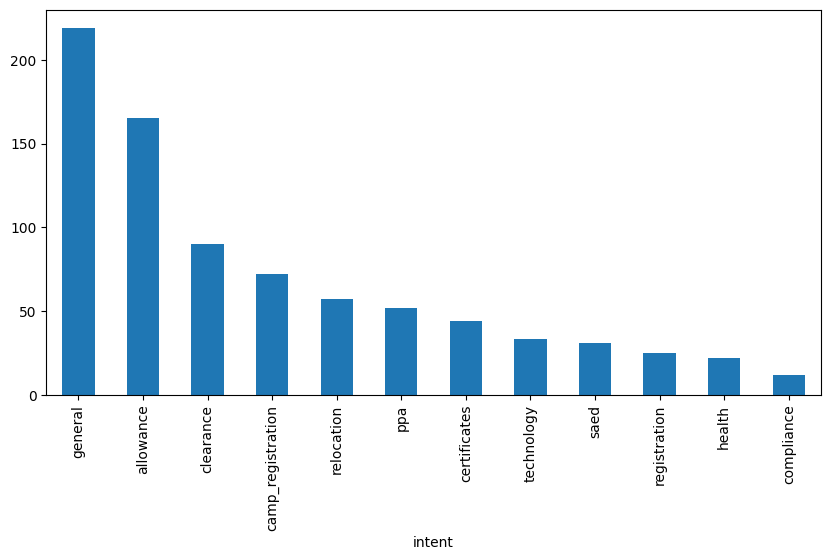

In [ ]:
# Display the intent value count distribution
plt.figure(figsize=(10,5))

df.intent.value_counts().plot.bar()


Intent Distribution:
intent
general              219
allowance            165
clearance             90
camp_registration     72
relocation            57
ppa                   52
certificates          44
technology            33
saed                  31
registration          25
health                22
compliance            12
Name: count, dtype: int64


/tmp/ipykernel_6039/2350837542.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=intent_counts.index, y=intent_counts.values, palette='viridis')


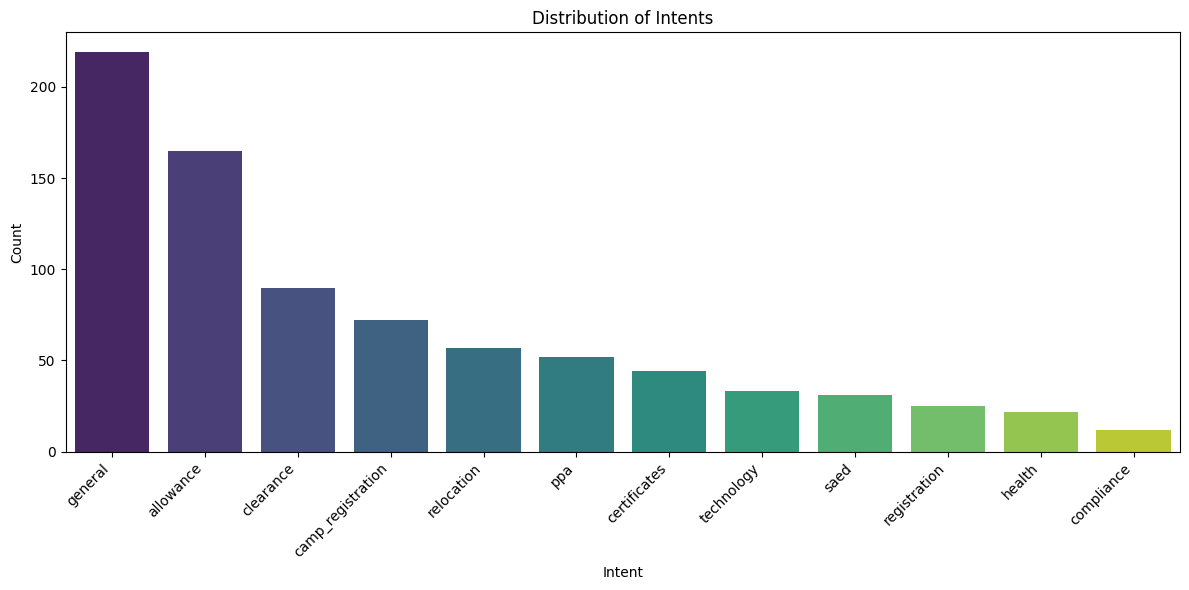

In [ ]:
# Check Intent distribution
print("\nIntent Distribution:")
intent_counts = df['intent'].value_counts()
print(intent_counts)
plt.figure(figsize=(12, 6))
sns.barplot(x=intent_counts.index, y=intent_counts.values, palette='viridis')
plt.title('Distribution of Intents')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Question Word Count Statistics:
count    822.000000
mean       6.675182
std        1.686904
min        3.000000
25%        6.000000
50%        6.000000
75%        8.000000
max       12.000000
Name: question_word_count, dtype: float64


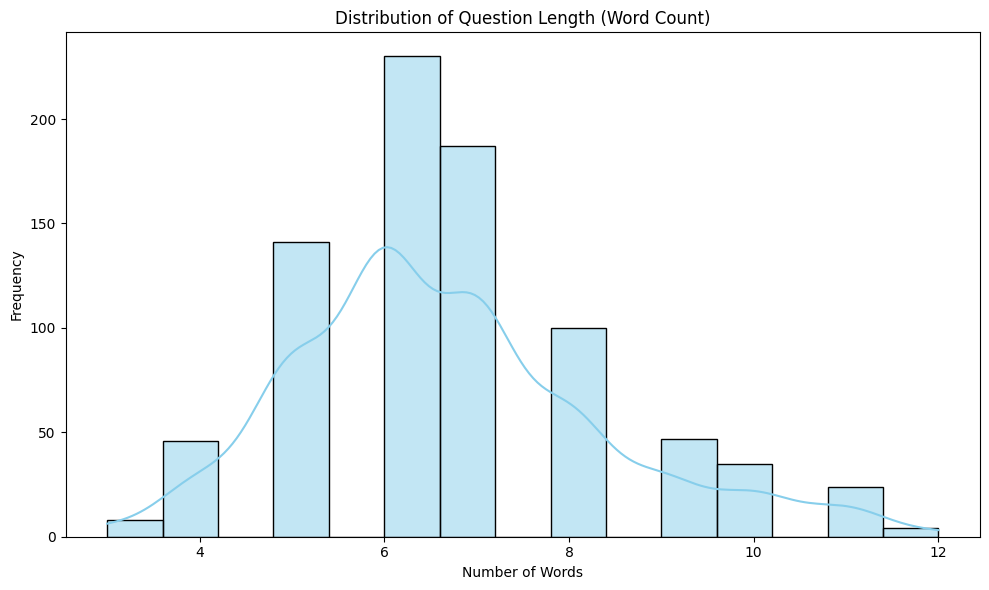

In [ ]:
# Check Question length distribution
df['question_word_count'] = df['question'].apply(lambda x: len(str(x).split()))

print("\nQuestion Word Count Statistics:")
print(df['question_word_count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['question_word_count'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Question Length (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# Check average words
print(f"\nAverage number of words per question: {df['question_word_count'].mean():.2f}")


Average number of words per question: 6.68


Natural Language Processing (NLP)

In [ ]:
# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# Initialize WordNetLemmatizer and PorterStemmer
wordnet_lemmatizer = WordNetLemmatizer()
porter_stemmer = PorterStemmer()

print("WordNetLemmatizer and PorterStemmer initialized.")

WordNetLemmatizer and PorterStemmer initialized.


MODEL TRAINING & EVALUATION PIPELINE

In [ ]:
X = df["clean_question"]
y = df["intent"].str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Check the training and testing samples
print(f"Training samples (X_train): {X_train.shape[0]} rows")
print(f"Testing samples (X_test): {X_test.shape[0]} rows")
print(f"Training labels (y_train): {y_train.shape[0]} rows")
print(f"Testing labels (y_test): {y_test.shape[0]} rows")

Training samples (X_train): 657 rows
Testing samples (X_test): 165 rows
Training labels (y_train): 657 rows
Testing labels (y_test): 165 rows


In [ ]:
# Initialize TfidfVectorizer and fit/transform the data
vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words="english", sublinear_tf=True, min_df=1, max_df=0.95)

vectorizer.fit(X_train)

X_train_vec = vectorizer.transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("Vectorizer fitted and data transformed successfully!")

Vectorizer fitted and data transformed successfully!


In [ ]:
# Defines the NYSCFAQChatbot class, which integrates data, vectorization, classification, and semantic search to respond to user queries with a fallback mechanism for low-confidence matches.
class NYSCFAQChatbot:
    def __init__(self, dataset, vectorizer, classifier, fallback_threshold=0.3):
        # Constructor for the chatbot.
        # Initializes the chatbot with the dataset, text vectorizer, intent classifier, and a confidence threshold for fallback.

        # Process the dataset: remove duplicate 'clean_question' entries and reset the index to ensure unique and consistent indexing.
        self.df = dataset.drop_duplicates(subset=['clean_question']).reset_index(drop=True)
        # Store the TF-IDF vectorizer, used for converting text to numerical features.
        self.vectorizer = vectorizer
        # Store the trained intent classifier (e.g., SVM, Logistic Regression).
        self.classifier = classifier
        # Set the confidence threshold below which the chatbot will provide a fallback response.
        self.fallback_threshold = fallback_threshold

        # Pre-compute the TF-IDF matrix for all questions in the dataset.
        # This allows for efficient semantic similarity comparison with user queries.
        self.corpus_tfidf = self.vectorizer.transform(self.df['clean_question'])

    def respond(self, user_query):
        # Main method to generate a response to a user's query.

        # Clean the user's input query using the defined clean_text function.
        cleaned_query = clean_text(user_query)
        # If the cleaned query is empty (e.g., user entered only punctuation), return a fallback response.
        if not cleaned_query:
            return self._fallback_response(user_query, 0.0)

        # Convert the cleaned user query into a TF-IDF vector.
        query_vec = self.vectorizer.transform([cleaned_query])

        # --- Intent Classification ---
        # Predict the probability of each intent class for the user's query.
        probs = self.classifier.predict_proba(query_vec)[0]
        # Find the index of the intent with the highest probability.
        max_prob_idx = np.argmax(probs)
        # Get the predicted intent label.
        predicted_intent = self.classifier.classes_[max_prob_idx]
        # Get the confidence score for the predicted intent.
        intent_confidence = float(probs[max_prob_idx])

        # --- Semantic Similarity (Cosine Similarity) ---
        # Calculate the cosine similarity between the user's query vector and all question vectors in the dataset.
        sim_scores = cosine_similarity(query_vec, self.corpus_tfidf).flatten()

        # Find the index of the question in the dataset that has the highest semantic similarity.
        best_match_idx = np.argmax(sim_scores)
        # Get the similarity score for the best-matched question.
        similarity_score = float(sim_scores[best_match_idx])

        # --- Combined Logic for Response Generation ---
        # If the highest semantic similarity score is below the predefined fallback threshold,
        # trigger the fallback response, indicating low confidence in finding a relevant answer.
        if similarity_score < self.fallback_threshold:
             return self._fallback_response(user_query, similarity_score)

        # Retrieve the full row from the dataset corresponding to the best-matched question.
        matched_row = self.df.iloc[best_match_idx]

        # Construct and return the chatbot's response as a dictionary.
        return {
            "query": user_query,
            "intent": matched_row['intent'], # The intent of the matched FAQ
            "category": matched_row.get('category', 'General'), # Category of the matched FAQ, with 'General' as default
            "matched_faq": matched_row['question'], # The exact FAQ question from the dataset that was matched
            "answer": matched_row['answer'], # The answer corresponding to the matched FAQ
            "confidence": round((intent_confidence + similarity_score) / 2, 3), # Combined confidence score
            "similarity_score": round(similarity_score, 3), # Raw semantic similarity score
            "is_fallback": False # Indicates that this is not a fallback response
        }

    def _fallback_response(self, user_query, confidence):
        # Private helper method to generate a standardized fallback response.
        # This is called when the chatbot cannot confidently answer a query.
        return {
            "query": user_query,
            "intent": "fallback", # Special intent for fallback scenarios
            "category": "Uncertain",
            "matched_faq": None, # No specific FAQ was matched
            "answer": "I'm sorry, I couldn't find a specific answer to that. Could you please rephrase or ask about NYSC registration, relocation, or allowances?",
            "confidence": round(confidence, 3),
            "similarity_score": 0.0, # Semantic similarity is considered 0 for fallback
            "is_fallback": True # Indicates that this is a fallback response
        }

print("Chatbot Engine updated with robust similarity matching.")

Chatbot Engine updated with robust similarity matching.


In [ ]:
# Initialize a dictionary of classification models including Logistic Regression, Linear SVM, and Naive Bayes, each configured with specific parameters.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42),
    "Naive Bayes": MultinomialNB()
}

print("Models dictionary created.")

Models dictionary created.


In [ ]:
# Initialize a dictionary to store model performance metrics for comparison.
model_performance = {}

# --- Evaluate Logistic Regression ---
# Get the Logistic Regression model from the 'models' dictionary.
best_logistic_model = models["Logistic Regression"]
# Train the Logistic Regression model on the vectorized training data and labels.
best_logistic_model.fit(X_train_vec, y_train)

# Make predictions on the vectorized test data.
lr_predictions = best_logistic_model.predict(X_test_vec)
# Calculate the accuracy score.
lr_accuracy = accuracy_score(y_test, lr_predictions)
# Calculate precision, recall, and F1-score (weighted average for multi-class).
lr_precision, lr_recall, lr_f1, _ = precision_recall_fscore_support(y_test, lr_predictions, average='weighted', zero_division=0)

# Store the Logistic Regression model's performance metrics.
model_performance['Logistic Regression'] = {
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1
}

# --- Evaluate Linear SVM ---
# Get the Linear SVM model from the 'models' dictionary.
linear_svm_eval_model = models["Linear SVM"]
# Train the Linear SVM model on the vectorized training data and labels.
linear_svm_eval_model.fit(X_train_vec, y_train)
# Make predictions on the vectorized test data.
svc_predictions = linear_svm_eval_model.predict(X_test_vec)
# Calculate the accuracy score.
svc_accuracy = accuracy_score(y_test, svc_predictions)
# Calculate precision, recall, and F1-score (weighted average for multi-class).
svc_precision, svc_recall, svc_f1, _ = precision_recall_fscore_support(y_test, svc_predictions, average='weighted', zero_division=0)

# Store the Linear SVM model's performance metrics.
model_performance['Linear SVM'] = {
    'Accuracy': svc_accuracy,
    'Precision': svc_precision,
    'Recall': svc_recall,
    'F1-Score': svc_f1
}

# --- Evaluate Multinomial Naive Bayes ---
# Initialize a new Multinomial Naive Bayes model.
mnb_model = MultinomialNB()
# Train the Naive Bayes model on the vectorized training data and labels.
mnb_model.fit(X_train_vec, y_train)
# Make predictions on the vectorized test data.
mnb_predictions = mnb_model.predict(X_test_vec)
# Calculate the accuracy score.
mnb_accuracy = accuracy_score(y_test, mnb_predictions)
# Calculate precision, recall, and F1-score (weighted average for multi-class).
mnb_precision, mnb_recall, mnb_f1, _ = precision_recall_fscore_support(y_test, mnb_predictions, average='weighted', zero_division=0)

# Store the Multinomial Naive Bayes model's performance metrics.
model_performance['Multinomial Naive Bayes'] = {
    'Accuracy': mnb_accuracy,
    'Precision': mnb_precision,
    'Recall': mnb_recall,
    'F1-Score': mnb_f1
}

# --- Create and Display Comparison Table ---
# Convert the 'model_performance' dictionary into a Pandas DataFrame for easy comparison.
comparison_df = pd.DataFrame.from_dict(model_performance, orient='index')
# Round the numerical metrics to 4 decimal places for cleaner display.
comparison_df = comparison_df.round(4)

# Print the title for the comparison table.
print("Model Comparison Table (re-trained):")
# Print the DataFrame showing the performance of each model.
print(comparison_df)

Model Comparison Table (re-trained):
                         Accuracy  Precision  Recall  F1-Score
Logistic Regression        0.8424     0.8475  0.8424    0.8289
Linear SVM                 0.8848     0.9049  0.8848    0.8856
Multinomial Naive Bayes    0.6909     0.7779  0.6909    0.6485


In [ ]:
# Create a Pandas DataFrame to summarize and display the accuracy of different models.
results = pd.DataFrame({
    # Define the 'Model' column with the names of the classifiers.
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    # Define the 'Accuracy' column with the previously calculated accuracy scores for each model.
    "Accuracy":[
        lr_accuracy,  # Accuracy for Logistic Regression
        mnb_accuracy, # Accuracy for Multinomial Naive Bayes
        svc_accuracy  # Accuracy for Linear SVM
    ]
})

# Display the 'results' DataFrame to show the model comparison.
results

,Model,Accuracy
0,Logistic Regression,0.842424
1,Naive Bayes,0.690909
2,Linear SVM,0.884848


In [ ]:
# Hyperparameter tuning for Linear SVM using GridSearchCV

# Define the hyperparameter grid for the Linear SVM. Here, we are tuning the 'C' parameter,which controls the trade-off between a smooth decision boundary and correctly classifying training points.
param_grid_svc = {
    'C': [0.1, 1, 10, 100]
}

# Initialize GridSearchCV.
grid_search_svc = GridSearchCV(models["Linear SVM"], param_grid_svc, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the vectorized training data.This performs the exhaustive search over the parameter grid using cross-validation.
grid_search_svc.fit(X_train_vec, y_train)

# Print the best hyperparameters found by GridSearchCV.
print("Best parameters for Linear SVM:", grid_search_svc.best_params_)
# Print the best cross-validation score achieved with these parameters.
print("Best cross-validation score for Linear SVM:", grid_search_svc.best_score_)

# Extract the best estimator (the SVM model with the optimal 'C' parameter) from the grid search results.
best_svm_model = grid_search_svc.best_estimator_
# Confirm that the Linear SVM model has been successfully tuned.
print("Linear SVM model tuned.")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters for Linear SVM: {'C': 10}
Best cross-validation score for Linear SVM: 0.8965186213277816
Linear SVM model tuned.


In [ ]:
# Evaluate the best SVM model on the test set
predictions = best_svm_model.predict(X_test_vec)

print(classification_report(
    y_test,
    predictions
))

print(
    accuracy_score(
        y_test,
        predictions
    )
)

                   precision    recall  f1-score   support

        allowance       0.94      0.94      0.94        33
camp_registration       1.00      0.87      0.93        15
     certificates       0.89      0.89      0.89         9
        clearance       0.94      0.89      0.91        18
       compliance       1.00      0.50      0.67         2
          general       0.80      0.93      0.86        44
           health       0.80      1.00      0.89         4
              ppa       1.00      0.90      0.95        10
     registration       1.00      0.80      0.89         5
       relocation       1.00      0.92      0.96        12
             saed       0.86      1.00      0.92         6
       technology       1.00      0.71      0.83         7

         accuracy                           0.90       165
        macro avg       0.94      0.86      0.89       165
     weighted avg       0.91      0.90      0.90       165

0.9030303030303031


In [ ]:
# Construct a machine learning pipeline that combines text vectorization with the best-tuned SVM classifier, then fit it to the training data.
best_classifier = best_svm_model # Use the re-tuned best_svm_model

pipeline = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", best_classifier)
])

pipeline.fit(X_train, y_train)
print("Pipeline created and fitted.")

Pipeline created and fitted.


In [ ]:
# Initialize the NYSC FAQ Chatbot with the processed data, vectorizer, best classifier, and a defined fallback threshold.
bot = NYSCFAQChatbot(
    df,
    vectorizer,
    best_classifier,
    fallback_threshold=0.5
)

In [ ]:
# Cross-validation for the best Logistic Regression model
cv_scores_lr = cross_val_score(best_logistic_model, X_train_vec, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"Cross-validation scores for Logistic Regression: {cv_scores_lr}")
print(f"Mean CV accuracy for Logistic Regression: {np.mean(cv_scores_lr):.4f}")

# Choosing SVC as the classifier for further steps
classifier = SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced')
classifier.fit(X_train_vec, y_train)
print("SVC classifier initialized and trained on training data.")

Cross-validation scores for Logistic Regression: [0.72727273 0.6969697  0.70992366 0.70229008 0.67938931]
Mean CV accuracy for Logistic Regression: 0.7032
SVC classifier initialized and trained on training data.


In [ ]:
# Perform cross-validation to assess the generalization performance of the best classifier.
scores = cross_val_score(
    best_classifier,
    X_train_vec,
    y_train,
    cv=5,
    scoring="accuracy"
)

# Print the accuracy scores from each fold of the cross-validation.
print(scores)

# Print the average accuracy score across all cross-validation folds.
# This provides a more robust estimate of the model's performance than a single train/test split.
print(scores.mean())

[0.90909091 0.87121212 0.88549618 0.90076336 0.91603053]
0.8965186213277816


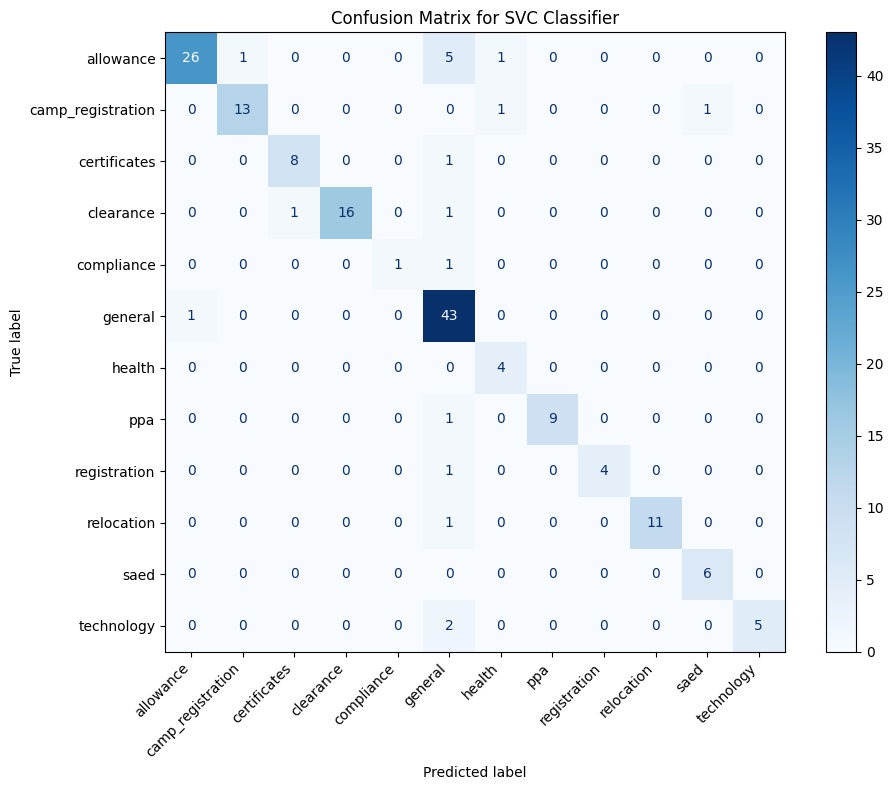

In [ ]:
# Display Confusion Matrix
# Initialize a figure and an axes object for the plot, specifying the figure size.
fig, ax = plt.subplots(figsize=(10, 8))

# Re-transform X_test using the globally updated vectorizer.This ensures the test data is in the correct numerical format (TF-IDF vectors) required by the ConfusionMatrixDisplay function.
X_test_vec_for_display = vectorizer.transform(X_test)

# Generate and display the confusion matrix.
ConfusionMatrixDisplay.from_estimator(classifier, X_test_vec_for_display, y_test, cmap=plt.cm.Blues, ax=ax)
# Set the title of the confusion matrix plot.
plt.title('Confusion Matrix for SVC Classifier')
# Rotate the x-axis labels for better readability, especially with many categories.
plt.xticks(rotation=45, ha='right')
# Automatically adjust plot parameters for a tight layout, preventing labels from overlapping.
plt.tight_layout()
# Display the generated confusion matrix plot.
plt.show()

NYSC FAQ CHATBOT ENGINE WITH FALLBACK

In [ ]:
# Re-instantiate the bot with the hardened indexing logic and trained model
bot = NYSCFAQChatbot(df, vectorizer, best_classifier, fallback_threshold=0.50)
print("Chatbot instance 'bot' has been successfully re-initialized with the updated model.")

Chatbot instance 'bot' has been successfully re-initialized with the updated model.


TESTING THE CHATBOT BY TAKING INPUT FROM USERS

In [ ]:
# Print introductory messages for the interactive chatbot session.
print("\n" + "="*60)
print("     INTERACTIVE CHATBOT EVALUATION ")
print("="*60)
print("Type your query or 'exit' to quit.\n")

# Start an infinite loop to continuously take user input.
while True:
    # Prompt the user to enter their query.
    user_input = input("👤 You: ")
    # Check if the user wants to exit the session.
    if user_input.lower() == 'exit':
        print("👋 Exiting interactive session.")
        break # Exit the loop if the user types 'exit'.

    # Get the chatbot's response to the user's query.
    res = bot.respond(user_input)

    # Print the details of the chatbot's response.
    print(f"\nQuestion          : {res['query']}")
    print(f"Detected intent   : {res['intent']} (Category: {res['category']})")
    print(f"Confidence %      : {res['confidence']:.2f}")
    # Conditionally print the matched FAQ or a fallback message.
    if res['matched_faq']:
        print(f"Matched FAQ       : {res['matched_faq']}")
    else:
        print(f"Matched FAQ       : None (This is a fallback response)")
    print(f"Answer            : {res['answer']}")
    print("-" * 60) # Print a separator for readability.


     INTERACTIVE CHATBOT EVALUATION 
Type your query or 'exit' to quit.

👤 You: What is NYSC? 

Question          : What is NYSC? 
Detected intent   : general (Category: General Enquiries)
Confidence %      : 0.99
Matched FAQ       : What is NYSC?
Answer            : The National Youth Service Corps (NYSC) is a mandatory one-year service program for Nigerian graduates under 30. It promotes national unity by deploying graduates to different states.
------------------------------------------------------------
👤 You: When will the NYSC allowance be paid? 

Question          : When will the NYSC allowance be paid? 
Detected intent   : allowance (Category: Allowance & Financials)
Confidence %      : 1.00
Matched FAQ       : When is NYSC allowance paid?
Answer            : NYSC allowance is paid monthly between the 25th and 30th of each month. Clearance is conducted during the first week (1st-10th). Posting announcements are made 3-5 days before camp opens.
---------------------------------

SAVE THE MODEL FOR DEPLOYMENT

In [ ]:
# Create a scikit-learn Pipeline that chains together the vectorizer and the classifier.This ensures that the same preprocessing (TF-IDF vectorization) is applied during inference as was applied during training, followed by classification.
pipeline = Pipeline([
    # First step: 'tfidf' (TF-IDF Vectorizer) transforms text data into numerical features.
    ("tfidf", vectorizer),
    # Second step: 'classifier' (the best-performing model, e.g., SVM) classifies the features.
    ("classifier", best_classifier)
])

# Save the entire trained pipeline to a file using joblib.This allows the trained model to be loaded and reused later without re-training, which is crucial for deployment.
joblib.dump(
    pipeline, # The pipeline object to save.
    "nysc_pipeline.joblib" # The filename for the saved pipeline.
)

['nysc_pipeline.joblib']

CREATE STREAMLIT APPLICATION FILE

In [ ]:
# Define the content of app.py as a multi-line string
app_content = '''
import streamlit as st
import pandas as pd
import joblib
import re
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline # Import Pipeline to correctly load the pipeline object

# Ensure clean_text function is available in app.py
def clean_text(text):
    """Advanced normalization: lowercasing, punctuation removal, and whitespace collapse."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text)
    return text.strip()

# Ensure NYSCFAQChatbot class is available in app.py
class NYSCFAQChatbot:
    def __init__(self, dataset, vectorizer, classifier, fallback_threshold=0.3):
        self.df = dataset.drop_duplicates(subset=['clean_question']).reset_index(drop=True)
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.fallback_threshold = fallback_threshold
        self.corpus_tfidf = self.vectorizer.transform(self.df['clean_question'])

    def respond(self, user_query):
        cleaned_query = clean_text(user_query)
        if not cleaned_query:
            return self._fallback_response(user_query, 0.0)

        query_vec = self.vectorizer.transform([cleaned_query])
        probs = self.classifier.predict_proba(query_vec)[0]
        max_prob_idx = np.argmax(probs)
        predicted_intent = self.classifier.classes_[max_prob_idx]
        intent_confidence = float(probs[max_prob_idx])

        sim_scores = cosine_similarity(query_vec, self.corpus_tfidf).flatten()
        best_match_idx = np.argmax(sim_scores)
        similarity_score = float(sim_scores[best_match_idx])

        if similarity_score < self.fallback_threshold:
             return self._fallback_response(user_query, similarity_score)

        matched_row = self.df.iloc[best_match_idx]

        return {
            "query": user_query,
            "intent": matched_row['intent'],
            "category": matched_row.get('category', 'General'),
            "matched_faq": matched_row['question'],
            "answer": matched_row['answer'],
            "confidence": round((intent_confidence + similarity_score) / 2, 3),
            "similarity_score": round(similarity_score, 3),
            "is_fallback": False
        }

    def _fallback_response(self, user_query, confidence):
        return {
            "query": user_query,
            "intent": "fallback",
            "category": "Uncertain",
            "matched_faq": None,
            "answer": "I'm sorry, I couldn't find a specific answer to that. Could you please rephrase or ask about NYSC registration, relocation, or allowances?",
            "confidence": round(confidence, 3),
            "similarity_score": 0.0,
            "is_fallback": True
        }

# Streamlit app logic
st.title("🇳🇬 NYSC Assistant")

# Load data and models
df = pd.read_excel('/content/nysc_faq_dataset.xlsx')
df['clean_question'] = df['question'].apply(clean_text) # Use the clean_text defined above

# Load the entire pipeline, then extract vectorizer and classifier
pipeline = joblib.load('nysc_pipeline.joblib')
vectorizer = pipeline.named_steps['tfidf']
classifier = pipeline.named_steps['classifier']

# Initialize chatbot
bot = NYSCFAQChatbot(df, vectorizer, classifier)

query = st.text_input("How can I help you today?")
if query:
    res = bot.respond(query)
    if res['is_fallback']:
        st.warning(res['answer'])
    else:
        st.success(res['answer'])
        st.caption(f"Source FAQ: {res['matched_faq']}")
'''

# Write the content to app.py
with open('app.py', 'w') as f:
    f.write(app_content)

print("app.py has been written using standard file I/O.")

app.py has been written using standard file I/O.


SETUP AND LAUNCH STREAMLIT DEPLOYMENT

In [ ]:
import subprocess
import sys
import time
import re

def get_installed_packages():
    """Get a list of installed packages and their versions."""
    reqs = subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'])
    return [r.decode().strip() for r in reqs.split()]

# Get all currently installed packages
installed_packages = get_installed_packages()

# Define the packages explicitly used in app.py
# These are the essential ones for the app to run
app_packages = [
    'streamlit',
    'pandas',
    'numpy',
    'scikit-learn',
    'joblib' # joblib is usually part of scikit-learn or a separate install
]

# Filter installed packages to only include the ones relevant for app.py
# This tries to match exact versions if possible for robustness
requirements_list = []
for app_pkg in app_packages:
    found = False
    for installed_pkg in installed_packages:
        if installed_pkg.startswith(app_pkg + '==') or installed_pkg.startswith(app_pkg.replace('-', '_') + '==' ): # Handle cases like scikit-learn vs sklearn
            requirements_list.append(installed_pkg)
            found = True
            break
    if not found: # If exact version not found, just add the package name
        requirements_list.append(app_pkg)

requirements_content = "\n".join(sorted(set(requirements_list)))

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

print("requirements.txt has been generated with the following content:")
print("-" * 30)
print(requirements_content)
print("-" * 30)

print("\nInstalling dependencies from requirements.txt...")
subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'], check=True)
print("Dependencies installed.")

print("\nDownloading cloudflared...")
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

print("Starting Streamlit app with cloudflared tunnel...")

# Start cloudflared in a separate process
process = subprocess.Popen(['./cloudflared-linux-amd64', 'tunnel', '--url', 'http://localhost:8501'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Give cloudflared some time to start and produce output
time.sleep(5)

public_url = None
start_time = time.time()
max_wait_time = 30 # seconds

while public_url is None and (time.time() - start_time) < max_wait_time:
    line = process.stderr.readline().decode('utf-8')  # Read from stderr
    if line:
        match = re.search(r'https://[a-zA-Z0-9.-]+\.trycloudflare\.com', line)
        if match:
            public_url = match.group(0)
            break
    else:
        time.sleep(1)

if public_url:
    print(f"\nYour Streamlit app is running at: {public_url}")
    print("\nNow, upload the following files to a GitHub repository for external deployment:")
    print("1. `app.py`")
    print("2. `nysc_pipeline.joblib`")
    print("3. `requirements.txt`")
    print("\nThen, go to Streamlit Cloud (share.streamlit.io), connect your GitHub repository, and deploy your app!")

    # Run the streamlit app in the background
    # This keeps the Colab cell running and serving the app
    subprocess.run([sys.executable, '-m', 'streamlit', 'run', 'app.py', '--server.port', '8501', '--server.enableCORS', 'False', '--server.enableXsrfProtection', 'False'])

else:
    print("Could not find public URL from cloudflared after several attempts.")
    print("Please check the output for errors or try running cloudflared manually.")
    # Attempt to print any accumulated stderr output for debugging
    while True:
        line = process.stderr.readline().decode('utf-8')
        if not line:
            break
        print(line.strip())

requirements.txt has been generated with the following content:
------------------------------
joblib==1.5.3
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
streamlit
------------------------------

Installing dependencies from requirements.txt...
Dependencies installed.

Starting Streamlit app with cloudflared tunnel...

Your Streamlit app is running at: https://guarantees-ratio-sunny-convicted.trycloudflare.com

Now, upload the following files to a GitHub repository for external deployment:
1. `app.py`
2. `nysc_pipeline.joblib`
3. `requirements.txt`

Then, go to Streamlit Cloud (share.streamlit.io), connect your GitHub repository, and deploy your app!
